# shwirl Python API — volume-render spectral cubes from a notebook

[shwirl](https://github.com/macrocosme/shwirl) renders astronomical spectral
cubes on the GPU with custom GLSL *transfer functions* (Vohl, Fluke, Barnes &
Hassan 2017, MNRAS). Besides the desktop app, the same renderer is scriptable:

- `Renderer` — offscreen rendering to numpy images, PNGs, and fly-around movies
- works on FITS files (plain or `.fits.gz`) or plain numpy arrays
- interactive exploration with ipywidgets sliders, all inside the notebook

**Install**

```bash
pip install shwirl[notebook]      # + ipywidgets, imageio
# optional extras:
pip install imageio-ffmpeg        # MP4 movie export
pip install jupyter_rfb           # live, mouse-rotatable canvas (r.canvas())
```


In [1]:
import numpy as np
import imageio.v3 as iio
from IPython.display import Image, display

from shwirl import Renderer, demo_cube

def show(img, scale=1.0):
    """Display an (H, W, 4) rendered frame inline (JPEG keeps the notebook light)."""
    display(Image(data=iio.imwrite("<bytes>", img[..., :3], extension=".jpg"),
                  width=int(img.shape[1] * scale)))


## 1. A first render

`demo_cube()` builds a small synthetic spectral cube (Gaussian blobs drifting
across velocity channels + noise) so this notebook runs without any downloads.
`Renderer` accepts a numpy array in `(channels, y, x)` order — or a FITS path,
as shown at the end.


self._volume_mean 0.09887877106666565
self._volume_std 0.09116586297750473
min: 0.0 max: 1.0


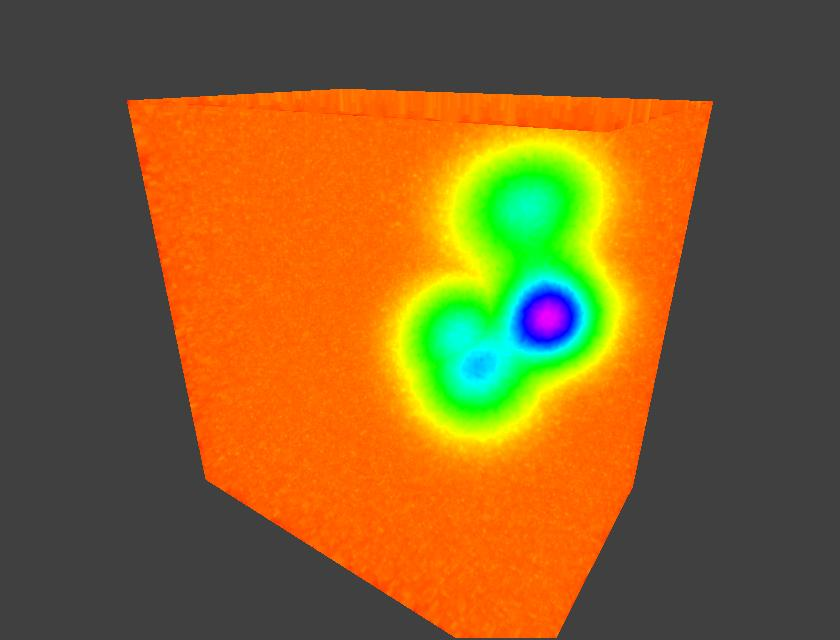

In [2]:
cube = demo_cube()                     # (64, 96, 96) float32
r = Renderer(cube, size=(420, 320))
r.method = "mip"                       # maximum intensity projection
r.cmap = "hsl"

show(r.render(azimuth=35, elevation=25))


## 2. Transfer functions

The transfer function decides how sample values along each ray combine into a
pixel. shwirl ships seven; here are three (`mip`, `avip`, `iso`):


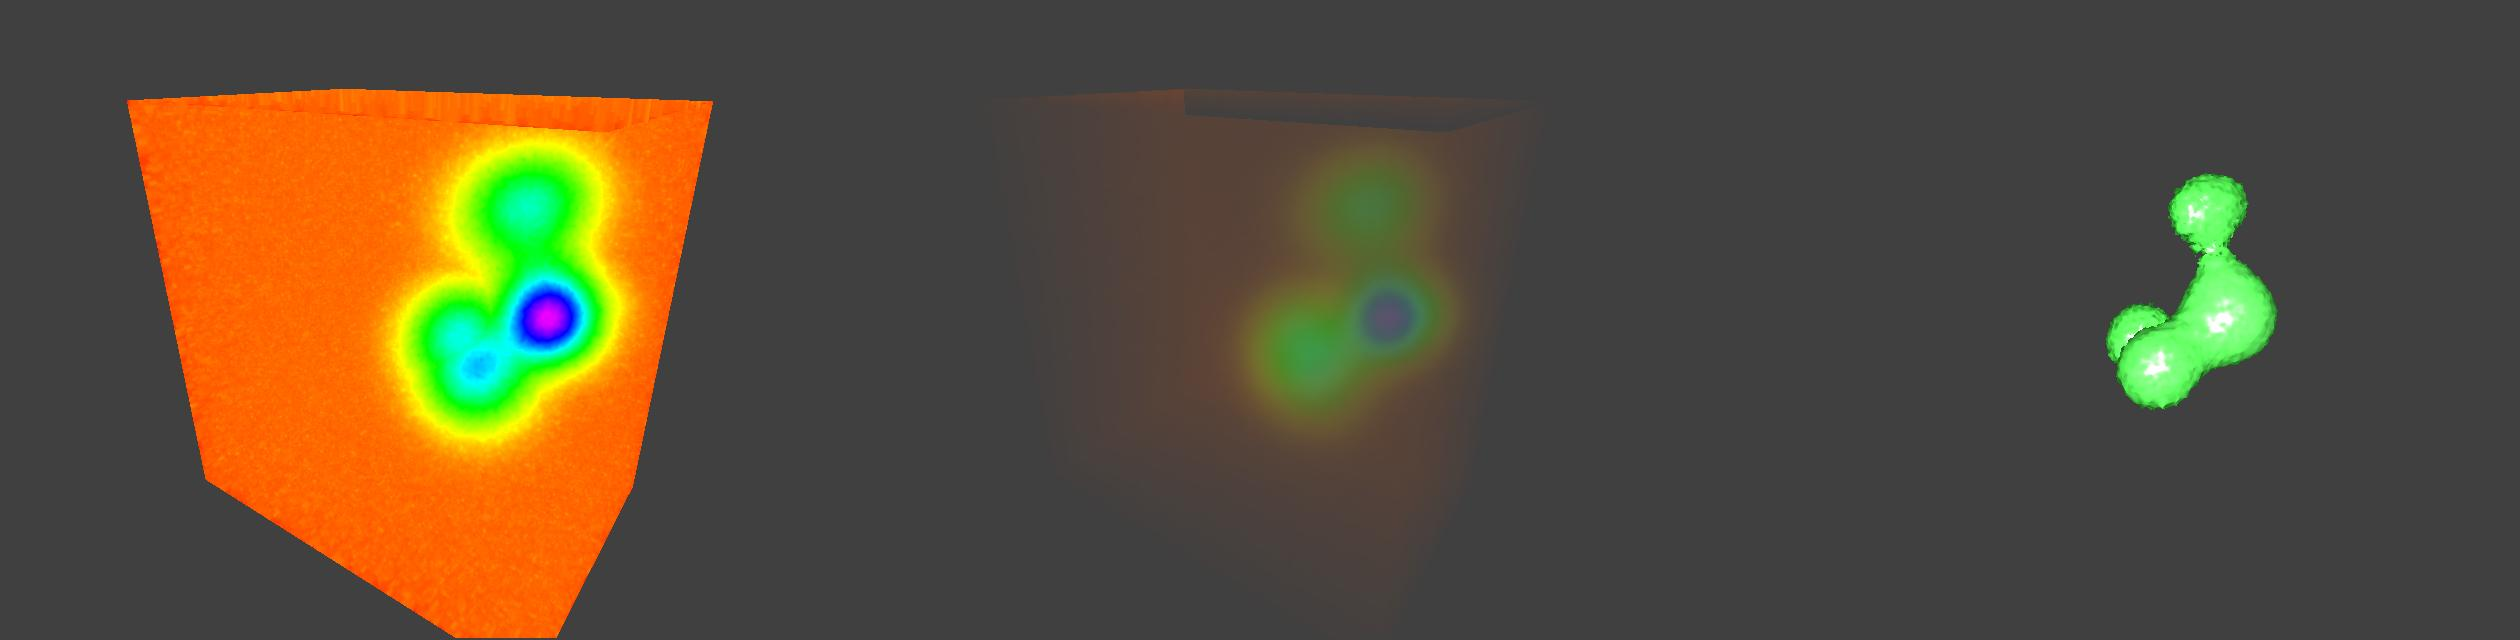

In [3]:
frames = []
for method in ("mip", "avip", "iso"):
    r.method = method
    if method == "avip":
        r.density_factor = 0.02
    if method == "iso":
        r.threshold = 0.4
    frames.append(r.render())
r.method = "mip"

show(np.hstack(frames), scale=0.8)     # left→right: mip, avip, iso


## 3. Dynamic-range stretches

Non-linear intensity stretches (cf. Rector et al. 2007) lift faint structure:
`linear`, `log`, `sqrt`, `asinh`, `power`. Compare linear vs log vs asinh —
watch the faint envelopes appear:


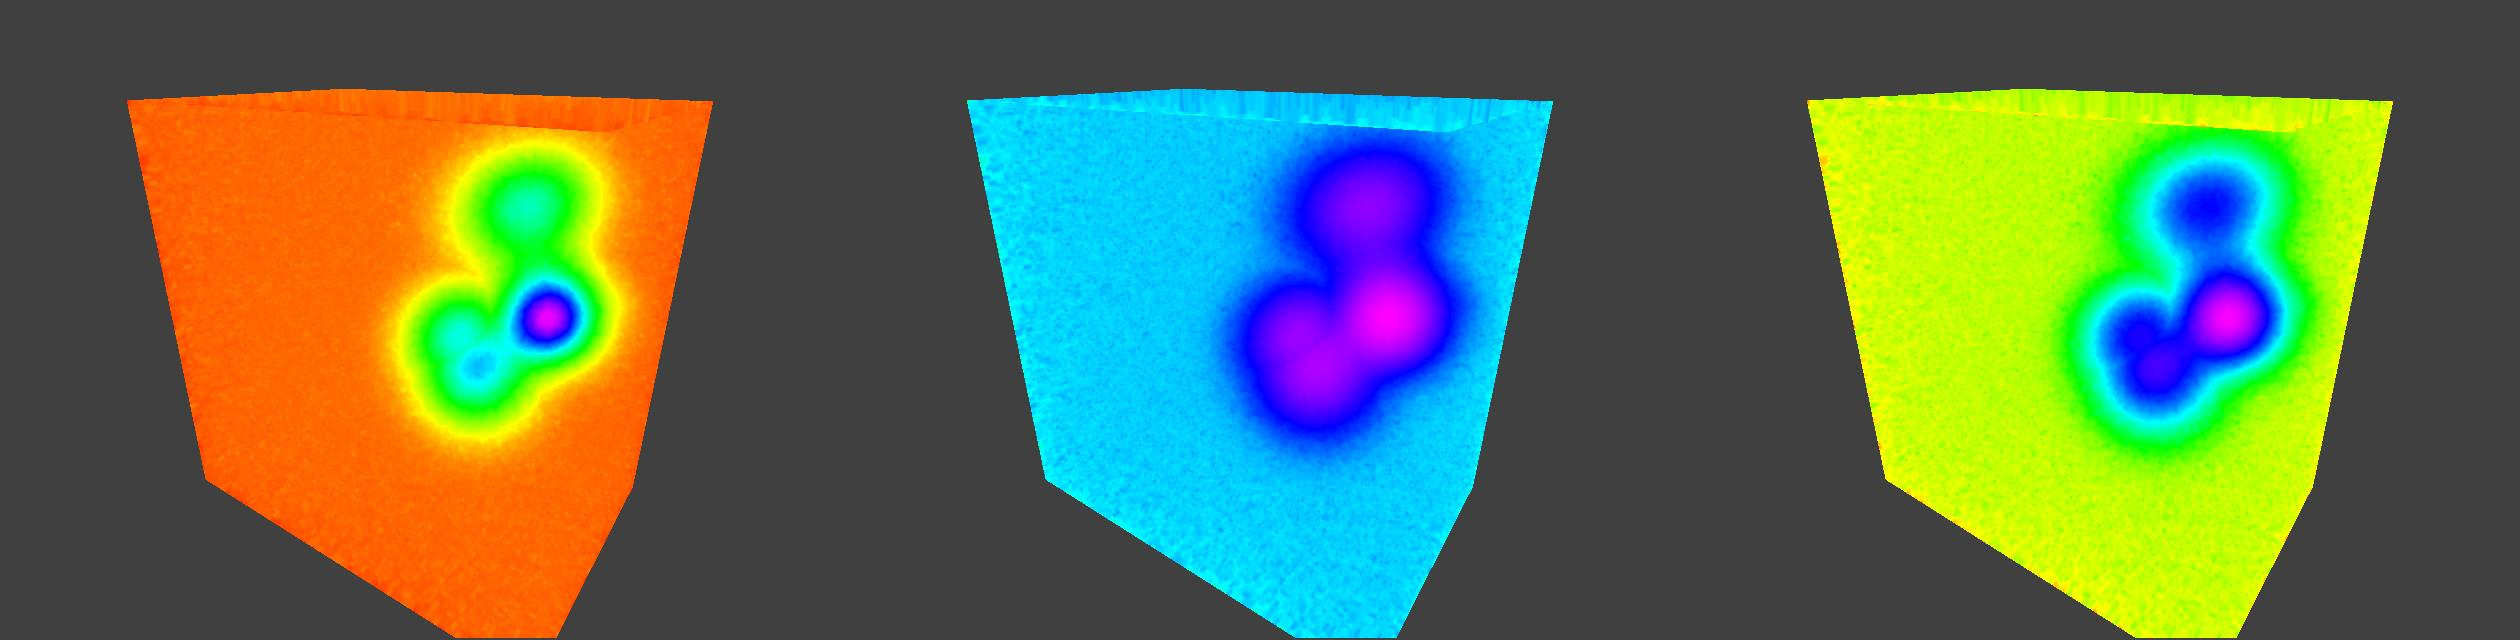

In [4]:
frames = []
for stretch in ("linear", "log", "asinh"):
    r.stretch = stretch
    frames.append(r.render())
r.stretch = "linear"

show(np.hstack(frames), scale=0.8)     # left→right: linear, log, asinh


## 4. Moment-1 style velocity colouring

`color_method="Moment 1"` colours voxels by their position along the spectral
axis (velocity) while intensity drives opacity — kinematics at a glance.


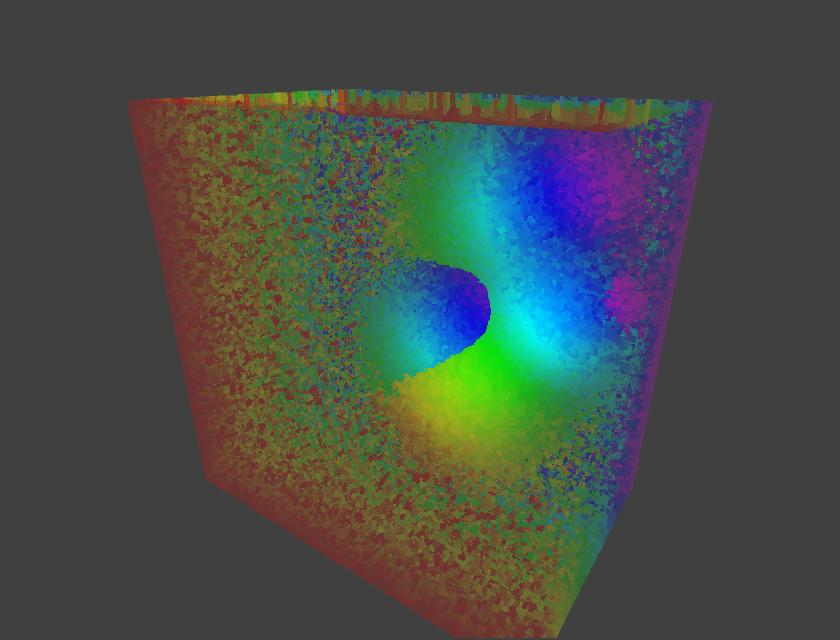

In [5]:
r.color_method = "Moment 1"
r.stretch = "asinh"                    # stretch acts on the opacity here
show(r.render())
r.color_method = "Moment 0"
r.stretch = "linear"


## 5. Publication assets: PNG + fly-around movie

`save()` writes a PNG; `save_movie()` spins the camera 360° and writes a GIF
(or MP4 with `imageio-ffmpeg` installed). Perfect for talks and papers.


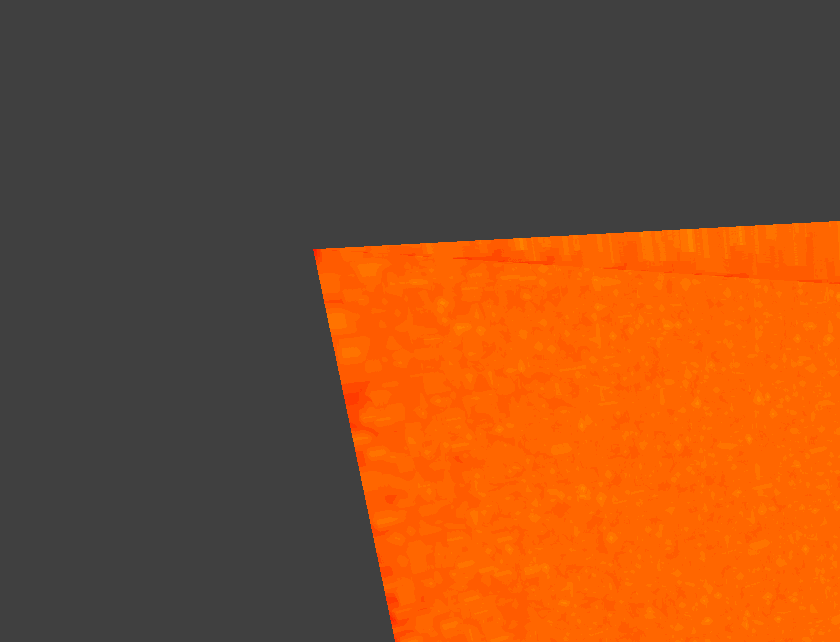

In [6]:
import tempfile
from pathlib import Path

outdir = Path(tempfile.mkdtemp())
r.save(outdir / "cube.png", azimuth=35, elevation=25)

# Small size/frame count keeps this demo GIF light; crank both up for real use.
gif = r.save_movie(outdir / "spin.gif", n_frames=16, fps=8, elevation=25,
                   size=(170, 130))
r.render(size=(420, 320))              # restore the working canvas size
display(Image(filename=str(gif)))


## 6. Interactive exploration

`widget()` builds an ipywidgets panel — change the transfer function, colormap,
stretch and camera with sliders; the view re-renders live. *(Run the notebook
to interact; widgets are inert in a static view.)*


In [7]:
r.widget()


## 7. Your own data

`Renderer` takes any FITS cube — gzipped included. Axis roles are inferred from
the WCS (the spectral axis becomes depth); degenerate axes (e.g. Stokes) are
squeezed automatically.

```python
r = Renderer("my_cube.fits")        # or my_cube.fits.gz
r.axis_info                         # WCS info per display axis
r.clim                              # data range mapped to the colormap
```

### Live, mouse-rotatable canvas

With `jupyter_rfb` installed, get a true interactive canvas (drag to rotate,
scroll to zoom) — the actual GL renderer streamed into the notebook:

```python
r.canvas()                          # requires: pip install jupyter_rfb
```
